# **AI620 ssignment 1: AI Labor Markets Analysis**
- `Name: Hasan Amjad` 
- `Roll number: 25280042`

This notebook performs data cleaning validation and exploratory analysis
for Kaggle, Adzuna, and Google Trends datasets as required in Assignment 1. 

## Answers: Part 1

### (a) Data Heterogeneity

The three selected data sources represent different data types and structural characteristics.
- Adzuna API – Semi-Structured Data (JSON format)
- Kaggle Dataset – Structured Data(CSV format)
- Google Trends – Time-Series Indexed Data

### (b) Extraction Challenges

Initially, Reddit was considered as the API source. However, API access restrictions and approval requirements limited immediate extraction capability. Due to these constraints, the Adzuna Jobs API was selected instead.

Trends didn't require any authentication. For Kaggle, I did use a token and ID to access and download dataset via terminal. For Azuna, Authentication required APP_ID and APP_KEY. Pagination was needed to retrieve multiple pages. However, didn't face any restriction as far as the enteries I extracted.  

### (c) Storage Justification

Some of the raw data was in JSON, and some in CSV. While processing, we stored it in both CSV and JSON formats for engineering flexibility. JSON preserves nested API structure, and could be used in some ingestion pipelines. However, CSV is more preferred, since I scanned it easily via third party software. And moreoever, pandas anaylsis were easily runnable. 


## Answers: Part 2

### (a) Cleaning Rationale

The datasets were largely complete, with most values available. However, i did add deleted some enteries to add some randomness. Some changes made were:

- Salary fields were converted to numeric format to enable aggregation and correlation analysis.
- Some columns contained empty strings instead of explicit null values; these were standardized.
- Rows with missing salary and skills were excluded during salary-based analysis.
- Synthetic missing values were introduced for demonstration purposes and replaced using median imputation to illustrate handling strategies.
- Duplicate records were checked and removed.


### (b) Visualization Insights

The datasets contained many categorical variables and relatively few continuous variables. Salary and job count were the primary continuous metrics analyzed. 

- Time series data frome trends showed that AI jobs were expontential rising in 2025-26
- Salary distributions vary across job titles and geographic locations. Principal AI applications engineers enjoy the highest salaries followed by Data Science roles.
- Found a positive correlation (r ≈ 0.28) between skill count and salary 

These findings align with the AI Labor Markets theme by connecting compensation, skill demand, and public interest signals.

---

### (c) Visualization Critique
We had a limited data from API, and since of most of data had a categorical values, establishing a mathamtical assosiation was challenging. However, in all three the jobs and salaries trend for AI and Data sciene jobs was consistent. 

## Analysis Part

In [70]:
#all libararies import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("All libraries installed")

All libraries installed


In [55]:

# Load cleaned datasets
kaggle = pd.read_csv('../data/cleaned/kaggle_jobs_cleaned.csv')
adzuna = pd.read_csv('../data/cleaned/adzuna_jobs_cleaned.csv') #Adzuna refers to API
trends = pd.read_csv('../data/cleaned/google_trends_processed_cleaned.csv')

# -----------------------------
# STANDARDIZE DATE COLUMNS
# -----------------------------

# --- Kaggle ---
kaggle_date_candidates = [
    'created',
    'posting_date',
    'job_posted_date',
    'date',
    'posted_on'
]

for col in kaggle_date_candidates:
    if col in kaggle.columns:
        kaggle['date'] = pd.to_datetime(kaggle[col], errors='coerce')
        break


# --- Adzuna ---
if 'created' in adzuna.columns:
    adzuna['date'] = pd.to_datetime(adzuna['created'], errors='coerce')


# --- Google Trends ---
if 'date' in trends.columns:
    trends['date'] = pd.to_datetime(trends['date'], errors='coerce')

## Data Quality Summary

In [68]:

# -------------------------------

# DATA QUALITY REPORT (Processed Data)
# -------------------------------
# Load processed datasets (NOT cleaned)
kaggle = pd.read_csv("../data/processed/kaggle_jobs.csv")
adzuna = pd.read_csv("../data/processed/adzuna_jobs.csv")

def data_quality_report(df, name):
    print(f"\n{name} DATA QUALITY REPORT")
    print("-" * 50)
    
    # Shape
    print("Dataset Shape:", df.shape)
    
    # Missing values per column
    missing_per_column = df.isna().sum()
    print("\nMissing Values Per Column:")
    print(missing_per_column)
    
    # Total missing values
    print("\nTotal Missing Values:", missing_per_column.sum())
    
    # Duplicate rows
    print("\nNumber of Duplicate Rows:", df.duplicated().sum())
    
    # Basic numeric summary
    print("\nNumeric Summary:")

# Run reports
data_quality_report(kaggle, "Kaggle (Processed)")
data_quality_report(adzuna, "Adzuna (Processed)")


Kaggle (Processed) DATA QUALITY REPORT
--------------------------------------------------
Dataset Shape: (692, 7)

Missing Values Per Column:
Title                 0
Company               0
Location              1
Type of Positions     1
Job Description       1
Salary               14
Identified_Skills    12
dtype: int64

Total Missing Values: 29

Number of Duplicate Rows: 392

Numeric Summary:

Adzuna (Processed) DATA QUALITY REPORT
--------------------------------------------------
Dataset Shape: (500, 8)

Missing Values Per Column:
id            0
title         0
company       0
location      0
salary_min    0
salary_max    0
created       0
category      0
dtype: int64

Total Missing Values: 0

Number of Duplicate Rows: 0

Numeric Summary:


## Temporal Analysis – Job Postings Over Time

C:\Users\hp\AppData\Local\Temp\ipykernel_26500\1701449701.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(adzuna_clean['date'].dt.to_period('W'))


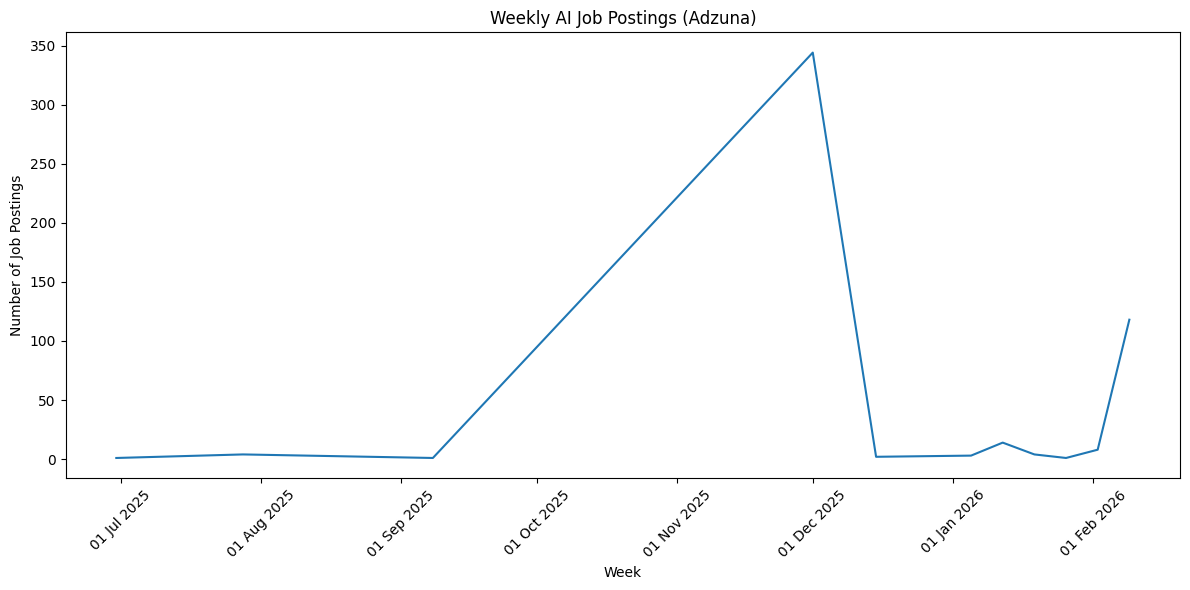

In [78]:
adzuna['date'] = pd.to_datetime(adzuna['created'])
# Ensure datetime
adzuna['date'] = pd.to_datetime(adzuna['date'], errors='coerce')

adzuna_clean = adzuna.dropna(subset=['date'])

# Weekly aggregation
weekly_counts = (
    adzuna_clean
    .groupby(adzuna_clean['date'].dt.to_period('W'))
    .size()
    .reset_index(name='job_count')
)

weekly_counts['date'] = weekly_counts['date'].dt.to_timestamp()

# Plot
plt.figure(figsize=(12, 6))

plt.plot(weekly_counts['date'], weekly_counts['job_count'])

# Correct formatter for weekly data
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))

plt.title('Weekly AI Job Postings (Adzuna)')
plt.xlabel('Week')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Google Trends Time-Series Analysis

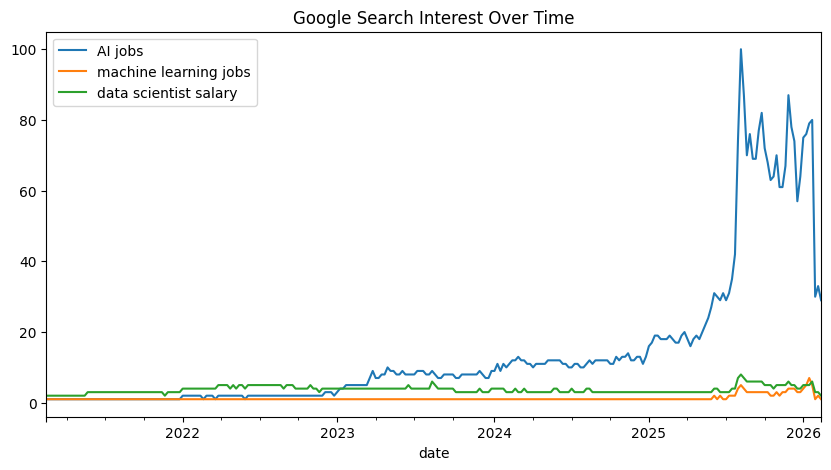

In [58]:
trends.set_index('date').plot(figsize=(10,5))
plt.title('Google Search Interest Over Time')
plt.show()

## Salary Distribution (Kaggle)

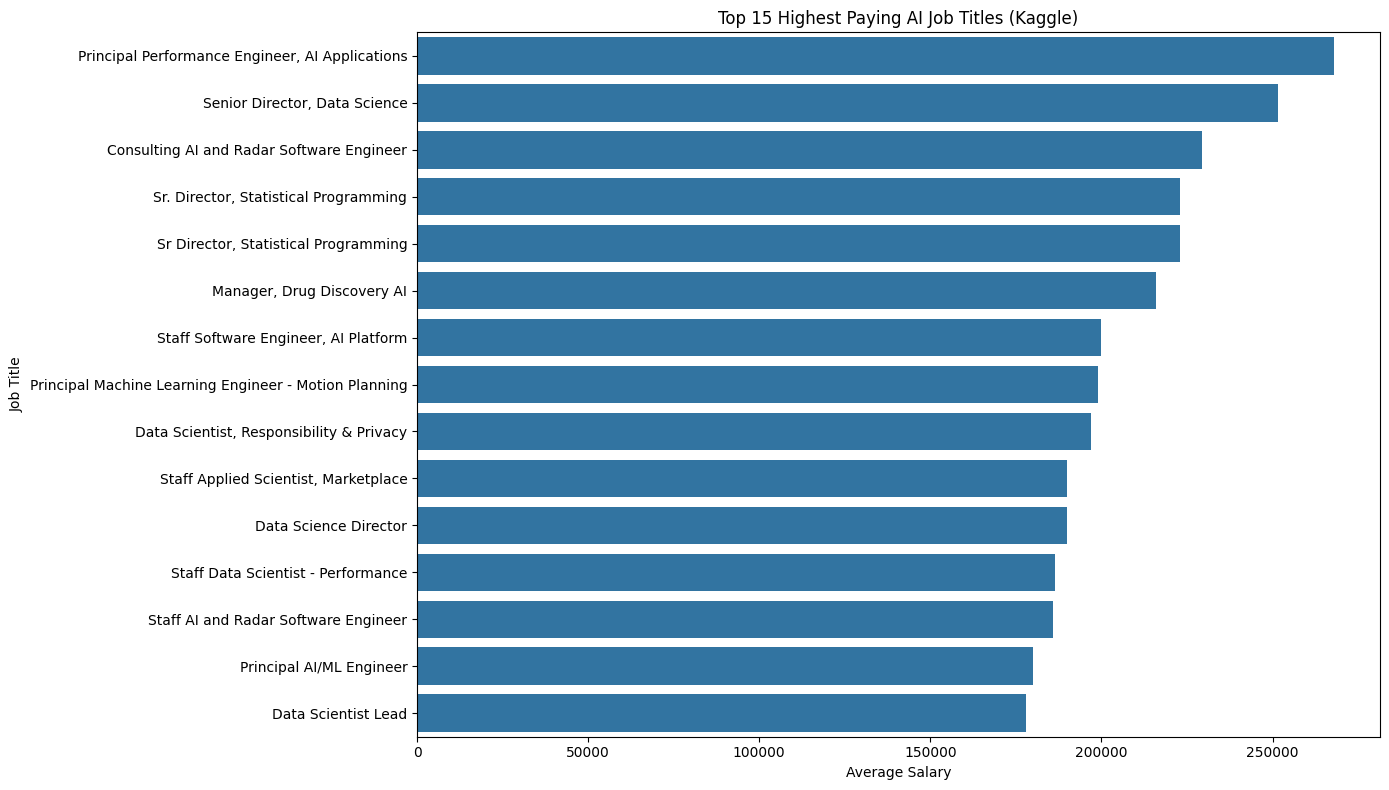

In [59]:

# Compute average salary per job title
top_titles = (
    kaggle
    .groupby('Title')['Salary']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

# Plot
plt.figure(figsize=(14,8))

sns.barplot(
    data=top_titles,
    x='Salary',
    y='Title'
)

plt.title('Top 15 Highest Paying AI Job Titles (Kaggle)')
plt.xlabel('Average Salary')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

## Correlation Analysis

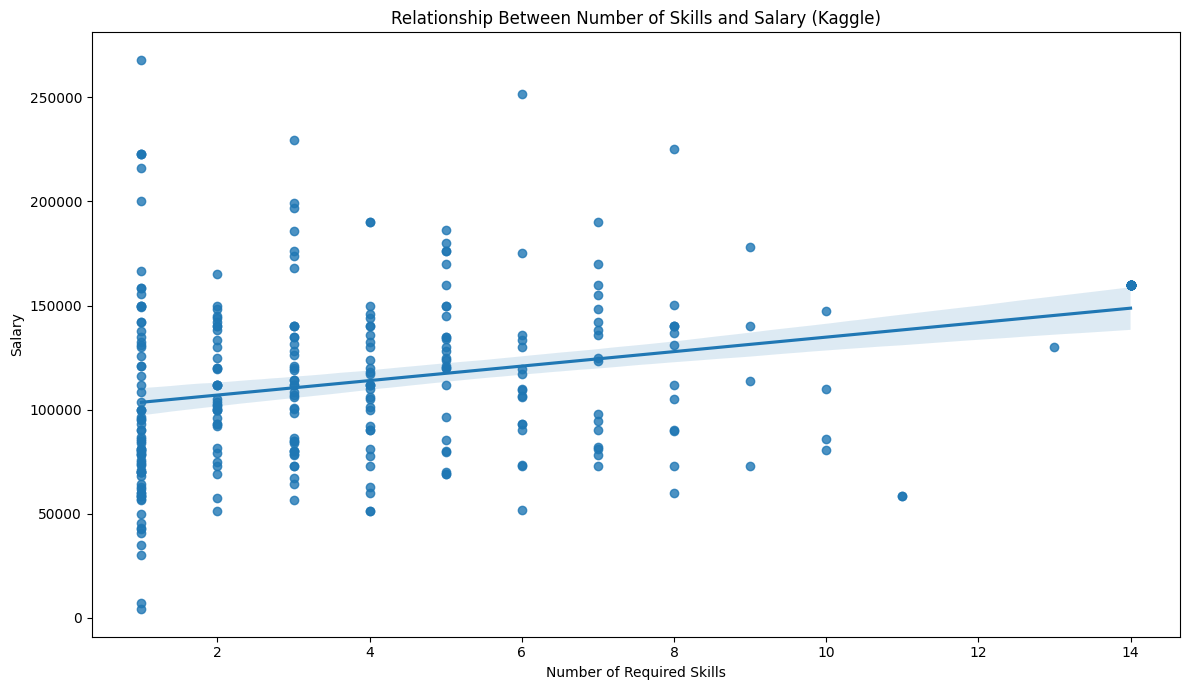

Correlation between skill count and salary: 0.2877425864576429


In [60]:

# Count skills safely by counting commas
kaggle['skill_count'] = kaggle['Identified_Skills'].apply(
    lambda x: 0 if x == 'nan' else x.count(',') + 1
)

# Remove rows with missing salary
kaggle_clean = kaggle.dropna(subset=['Salary'])

# Plot relationship
plt.figure(figsize=(12, 7))

sns.regplot(
    data=kaggle_clean,
    x='skill_count',
    y='Salary'
)

plt.title('Relationship Between Number of Skills and Salary (Kaggle)')
plt.xlabel('Number of Required Skills')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

# Print correlation
correlation = kaggle_clean['skill_count'].corr(kaggle_clean['Salary'])
print("Correlation between skill count and salary:", correlation)